# Assignement 4

Analyzing the Twitter Data. For this purpose follow the following steps: 
- a. Create developer’s account on twitter. One account is sufficient across 8 to 10 students.
- b. Scrap the twitter data using tweepy library. It must be done using five keywords of your choice.
- c. Use a word embedding such as GloVe and FastText to convert each tweet into vector form
- d. Perform the kmeans clustering using cosine similarity measure

I have already scrapped the Twitter data locally and uploaded the scrapped data to kaggle inputs. 

[Twitter Data](https://www.kaggle.com/datasets/debatreyadas/twitter-data-100x31)
Shape (100 Rows and 31 Columns)

## Load the dataset and Select 4 columns 
('tweet_id', 'created_at', 'text', 'lang') are the selected features

In [1]:
# Importing pandas
import pandas as pd

# Loading data
df = pd.read_csv('/kaggle/input/twitter-data-100x31/all_tweets.csv')

df.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pan

,tweet_id,created_at,text,author_id,conversation_id,in_reply_to_user_id,lang,possibly_sensitive,source,like_count,...,media_width,media_height,place_name,place_country,place_latitude,place_longitude,poll_duration_minutes,poll_end_time,poll_status,poll_options
0,1900449867664626115,2025-03-14 07:32:11+00:00,@vibeofswetha @AshokDharbal @rishibagree Flexi...,1816315585363599361,1900063037458927631,1.738046e+18,en,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1900449820789133743,2025-03-14 07:32:00+00:00,RT @Wat_the_deuce: Monty Python 😁 https://t.co...,1373580142765805573,1900449820789133743,NaN,cy,NaN,NaN,0,...,720.0,1024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1900449800027271244,2025-03-14 07:31:55+00:00,RT @quantscience_: 🚨BREAKING: A new Python lib...,23241398,1900449800027271244,NaN,en,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1900449796864852058,2025-03-14 07:31:54+00:00,ストレスMAXでほぼ3日間ごろ寝のみで過ごした状態で本屋に寄っちゃダメだった🤦‍♀️\n\n...,1573286778668453888,1900449796864852058,NaN,ja,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1900449779596840988,2025-03-14 07:31:50+00:00,"Yes I am very capable, mainly on python or win...",746566256350756864,1900449779596840988,NaN,en,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
df.shape

(100, 31)

In [3]:
df.columns

Index(['tweet_id', 'created_at', 'text', 'author_id', 'conversation_id',
       'in_reply_to_user_id', 'lang', 'possibly_sensitive', 'source',
       'like_count', 'retweet_count', 'reply_count', 'quote_count', 'username',
       'user_name', 'user_created_at', 'user_protected', 'user_verified',
       'media_type', 'media_url', 'media_duration_ms', 'media_width',
       'media_height', 'place_name', 'place_country', 'place_latitude',
       'place_longitude', 'poll_duration_minutes', 'poll_end_time',
       'poll_status', 'poll_options'],
      dtype='object')

### Selecting Relevant columns
- created_at (When the post is created)
- text
- lang
- like_count
- retweet_count
- reply_count
- user_created_at

In [4]:
# Select relevant columns
df = df[['created_at', 'text', 'lang', 'like_count', 'retweet_count', 'reply_count', 'user_created_at']]

df.shape

(100, 7)

In [5]:
df.head()

,created_at,text,lang,like_count,retweet_count,reply_count,user_created_at
0,2025-03-14 07:32:11+00:00,@vibeofswetha @AshokDharbal @rishibagree Flexi...,en,0,0,0,2024-07-25 03:32:53+00:00
1,2025-03-14 07:32:00+00:00,RT @Wat_the_deuce: Monty Python 😁 https://t.co...,cy,0,46,0,2021-03-21 10:20:42+00:00
2,2025-03-14 07:31:55+00:00,RT @quantscience_: 🚨BREAKING: A new Python lib...,en,0,324,0,2009-03-07 22:14:00+00:00
3,2025-03-14 07:31:54+00:00,ストレスMAXでほぼ3日間ごろ寝のみで過ごした状態で本屋に寄っちゃダメだった🤦‍♀️\n\n...,ja,0,0,0,2022-09-23 12:23:02+00:00
4,2025-03-14 07:31:50+00:00,"Yes I am very capable, mainly on python or win...",en,0,0,0,2016-06-25 04:50:41+00:00


## Using GloVe for word embedding 
## and then kMeans CLustering (with cosine similarity)

In [6]:
import numpy as np
from tqdm import tqdm

# Path to GloVe file
glove_path = '/kaggle/input/glove6b100dtxt/glove.6B.100d.txt'

# Load GloVe embeddings into a dictionary
embeddings_index = {}
with open(glove_path, encoding='utf8') as f:
    for line in tqdm(f, desc="Loading GloVe embeddings"):
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# Function to convert a tweet to a vector using GloVe embeddings
def get_embedding(text):
    words = text.split()
    valid_words = [embeddings_index[word] for word in words if word in embeddings_index]
    if len(valid_words) == 0:
        return np.zeros(100)  # Return zero vector if no valid words
    return np.mean(valid_words, axis=0)

# Convert tweets to vectors
tqdm.pandas()
df['vector'] = df['text'].progress_apply(get_embedding)

# Stack vectors into a matrix
X_glove = np.vstack(df['vector'].values)

# Check vector shape
print(X_glove.shape)

Loading GloVe embeddings: 400000it [00:11, 35712.25it/s]
100%|██████████| 100/100 [00:00<00:00, 21604.53it/s]

(100, 100)


###  KMeans clustering using cosine similarity in case of GloVe embedding
Use KMeans with cosine similarity.
Convert cosine similarity to distance (1 - cosine similarity).

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

# Number of clusters
n_clusters = 5

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(X_glove)

# Convert to cosine distance matrix
distance_matrix = 1 - similarity_matrix

# KMeans clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster_glove'] = kmeans.fit_predict(distance_matrix)

print('Sample Clusters (5 clusters)')
# Show sample clusters
for cluster in range(n_clusters):
    print(f"\nCluster {cluster} (GloVe):")
    print(df.loc[df['cluster_glove'] == cluster, ['text', 'lang']].head(5))

Sample Clusters (5 clusters)

Cluster 0 (GloVe):
                                                text lang
0  @vibeofswetha @AshokDharbal @rishibagree Flexi...   en
4  Yes I am very capable, mainly on python or win...   en
5  @TechWithArian @iamarsibragimov I learned pyth...   en
7  RT @coder_surya: 85.65 GB All paid Courses Col...   en
9  RT @report_with_ai: Complimentary PDF Book: Le...   en

Cluster 1 (GloVe):
                                                 text lang
1   RT @Wat_the_deuce: Monty Python 😁 https://t.co...   cy
3   ストレスMAXでほぼ3日間ごろ寝のみで過ごした状態で本屋に寄っちゃダメだった🤦‍♀️\n\n...   ja
8   @kato82 もっとガッツリした言語……pythonとか。\nああいうのを素人さんがやるよ...   ja
48  @zumipro_design 先行販売の希望ありがとうございます！\nこちらからご確認くだ...   ja
52  RT @dataduck_: duckdb를 왜 mysql, postgreSQL과 비교...   ko

Cluster 2 (GloVe):
                                                 text lang
41  Faire du design system avec Flutter c'est vrai...   fr
44  Faire du design system avec Flutter c'est vrai...   fr
46  RT @luucaspole: hoje me depa

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


## Load FastText model and create embeddings
## and and then kMeans CLustering (with cosine similarity)

In [8]:
!pip install gensim

In [9]:
import numpy as np
from tqdm import tqdm
from gensim.models.fasttext import FastText

# Load FastText embeddings
fasttext_path = '/kaggle/input/fasttext-vectors/cc.en.300.bin'
fasttext = FastText.load_fasttext_format(fasttext_path)  # FIXED

# Initialize tqdm for apply operations
tqdm.pandas()

# Function to convert tweet to FastText vector
def get_fasttext_embedding(text):
    words = text.split()
    valid_words = [fasttext.wv[word] for word in words if word in fasttext.wv]
    if not valid_words:
        return np.zeros(fasttext.vector_size)  # Return zero vector if no valid words
    return np.mean(valid_words, axis=0)

# Convert tweets to vectors
df['vector_fasttext'] = df['text'].progress_apply(get_fasttext_embedding)

# Stack vectors into a matrix
X_fasttext = np.vstack(df['vector_fasttext'].values)

# Check vector shape
print(X_fasttext.shape)  # (num_tweets, 300)

<ipython-input-9-5dbb4905880d>:7: DeprecationWarning: Call to deprecated `load_fasttext_format` (use load_facebook_vectors (to use pretrained embeddings) or load_facebook_model (to continue training with the loaded full model, more RAM) instead).
  fasttext = FastText.load_fasttext_format(fasttext_path)  # FIXED
100%|██████████| 100/100 [00:00<00:00, 4883.17it/s]

(100, 300)


### kMeans Clustering with cosine relationship in case of fastText embedding

In [10]:
# Compute cosine similarity matrix
similarity_matrix_fasttext = cosine_similarity(X_fasttext)

# Convert to cosine distance matrix
distance_matrix_fasttext = 1 - similarity_matrix_fasttext

# KMeans clustering
kmeans_fasttext = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster_fasttext'] = kmeans_fasttext.fit_predict(distance_matrix_fasttext)

print(print('Sample Clusters (5 clusters)'))
# Show sample clusters
for cluster in range(n_clusters):
    print(f"\nCluster {cluster} (FastText):")
    print(df.loc[df['cluster_fasttext'] == cluster, ['text', 'lang']].head(5))

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Sample Clusters (5 clusters)
None

Cluster 0 (FastText):
                                                 text lang
11  RT @sabir_huss50540: If you’re interested in L...   en
18  RT @BirdTrack: BirdTrack data shows that the b...   en
19  RT @sabir_huss50540: If you’re interested in L...   en
21  RT @RedHat: Not every #AI project needs a huge...   en
22  RT @RedHat: Not every #AI project needs a huge...   en

Cluster 1 (FastText):
                                                 text lang
1   RT @Wat_the_deuce: Monty Python 😁 https://t.co...   cy
6   RT @ChehadeTheKing: COYOTE &amp; AB-SOUL\n\n“R...   en
20  ඔන්න දැන් කැම්පස් එකේ Last Year එකේ Compiler D...   si
37  DeepSeekAP - Artificial #Physicals\n\nWeb∞\n#H...   et
41  Faire du design system avec Flutter c'est vrai...   fr

Cluster 2 (FastText):
                                                 text lang
2   RT @quantscience_: 🚨BREAKING: A new Python lib...   en
7   RT @coder_surya: 85.65 GB All paid Courses Col...   en
9   RT @repo

## Comparing Cluster Results

In [12]:
# Compare GloVe and FastText clusters side-by-side
for i in range(n_clusters):
    print(f"\nCluster {i} (GloVe):")
    print(df.loc[df['cluster_glove'] == i, ['text', 'lang']].head(3))

    print(f"\nCluster {i} (FastText):")
    print(df.loc[df['cluster_fasttext'] == i, ['text', 'lang']].head(3))


Cluster 0 (GloVe):
                                                text lang
0  @vibeofswetha @AshokDharbal @rishibagree Flexi...   en
4  Yes I am very capable, mainly on python or win...   en
5  @TechWithArian @iamarsibragimov I learned pyth...   en

Cluster 0 (FastText):
                                                 text lang
11  RT @sabir_huss50540: If you’re interested in L...   en
18  RT @BirdTrack: BirdTrack data shows that the b...   en
19  RT @sabir_huss50540: If you’re interested in L...   en

Cluster 1 (GloVe):
                                                text lang
1  RT @Wat_the_deuce: Monty Python 😁 https://t.co...   cy
3  ストレスMAXでほぼ3日間ごろ寝のみで過ごした状態で本屋に寄っちゃダメだった🤦‍♀️\n\n...   ja
8  @kato82 もっとガッツリした言語……pythonとか。\nああいうのを素人さんがやるよ...   ja

Cluster 1 (FastText):
                                                 text lang
1   RT @Wat_the_deuce: Monty Python 😁 https://t.co...   cy
6   RT @ChehadeTheKing: COYOTE &amp; AB-SOUL\n\n“R...   en
20  ඔන්න දැන් කැම්පස් එකේ Last Year එ

## Comparing with Plots
1. PCA (Principal Component Analysis) – Linear dimensionality reduction
2. t-SNE (t-Distributed Stochastic Neighbor Embedding) – Non-linear dimensionality reduction (better for visualizing clusters)
3. UMAP (Uniform Manifold Approximation and Projection) – Similar to t-SNE but faster

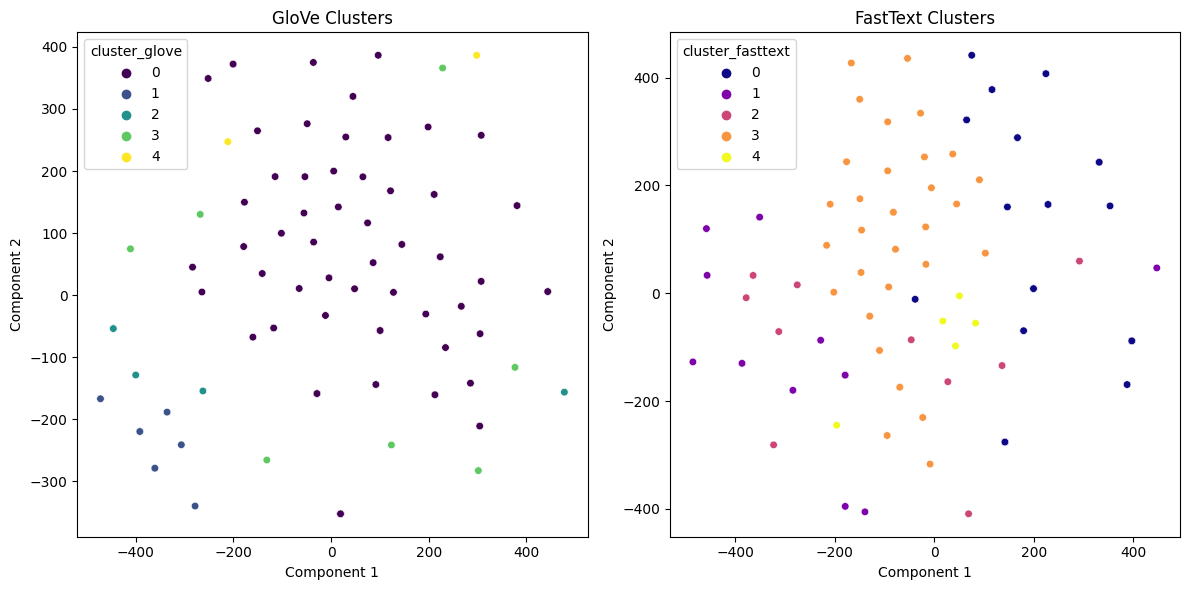

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Reduce GloVe vectors to 2D using t-SNE
tsne_glove = TSNE(n_components=2, random_state=42)
X_glove_2d = tsne_glove.fit_transform(X_glove)

# Reduce FastText vectors to 2D using t-SNE
tsne_fasttext = TSNE(n_components=2, random_state=42)
X_fasttext_2d = tsne_fasttext.fit_transform(X_fasttext)

# Plot GloVe clusters
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(
    x=X_glove_2d[:, 0], y=X_glove_2d[:, 1],
    hue=df['cluster_glove'],
    palette='viridis',
    s=30
)
plt.title('GloVe Clusters')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

# Plot FastText clusters
plt.subplot(1, 2, 2)
sns.scatterplot(
    x=X_fasttext_2d[:, 0], y=X_fasttext_2d[:, 1],
    hue=df['cluster_fasttext'],
    palette='plasma',
    s=30
)
plt.title('FastText Clusters')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

plt.tight_layout()
plt.show()